# Frio e coração: replicando um estudo publicado

**A pergunta:** em julho de 2026, a revista *PLOS Global Public Health* publicou
um estudo ecológico brasileiro sobre a relação entre temperatura e internações
cardiovasculares — 2,9 milhões de internações em 103 cidades, de 2010 a 2024
([Dóris e cols., 2026](https://doi.org/10.1371/journal.pgph.0005294)). Ele usou
o SIH/DATASUS: exatamente a base que abrimos aqui.

Este notebook faz duas coisas com isso. Primeiro, **confere se os nossos números
batem com os publicados** — um teste honesto de que a extração e a definição de
caso estão corretas. Depois, **testa a hipótese central do estudo** com dados
completos, usando o SIM.

**Fonte:** SIH/SUS e SIM/DATASUS, com denominadores do IBGE.

**Tempo estimado:** 20 a 40 minutos na primeira vez. Ele baixa o SIH mês a mês de 2010 a 2024 para dois estados — são centenas de arquivos. Medido: 21 minutos com os arquivos já em cache, mais de 30 sem eles. Deixe rodando e volte depois.

**O que você leva daqui:** a definição de caso cardiovascular do estudo em
código reaproveitável, um método para conferir seus resultados contra a
literatura, e o retrato da sazonalidade cardiovascular no Brasil.

## O que dá e o que não dá para replicar

Antes de qualquer código, o que este notebook **não** faz — e por quê. Um
exemplo que promete replicar um estudo e entrega outra coisa é pior que
nenhum exemplo.

| O estudo fez | Aqui |
|---|---|
| Contagem de internações cardiovasculares pelo SIH | **Sim** — mesma base, mesma definição de CID-10 |
| Série diária de 2010 a jun/2024 | **Não** — o espelho do PySUS publica poucos meses do grupo RD do SIH por ano; um recorte diário contínuo de 14 anos não é possível por aqui |
| Temperatura diária das estações do INMET | **Não** — o INMET não faz parte da PySUS, e a interface pública dele não se mostrou estável o bastante para um exemplo que precisa funcionar por anos |
| Modelo DLNM com meta-análise em dois estágios | **Não** — exige pacotes de R (`dlnm`, `mvmeta`) sem equivalente direto aqui, e foge do propósito deste repositório |
| Comparar clima temperado e tropical | **Sim, por outro caminho** — usando o mês do ano como marcador de estação, e o SIM, que tem a série completa |

Ou seja: replicamos **a definição de caso e a pergunta**, não o modelo
estatístico. É o que dá para fazer com honestidade — e já é bastante.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. A definição de caso do estudo, em código

O artigo lista os códigos da CID-10 que contou como evento cardiovascular.
Transcrevê-los é o primeiro passo de qualquer replicação — e é onde a maioria
das tentativas já se perde, porque cada estudo escolhe um recorte diferente.

In [4]:
# Códigos da CID-10 exatamente como descritos no artigo.
GRUPOS_DO_ESTUDO = {
    "Infarto agudo do miocárdio": [21, 22],
    "Outras doenças isquêmicas": [20, 23, 24, 25],
    "Arritmias e distúrbios de condução": list(range(44, 50)),
    "Insuficiência cardíaca": [50],
    "Infarto cerebral": [63],
    "AVC não especificado": [64],
}
CODIGOS = sorted({n for lista in GRUPOS_DO_ESTUDO.values() for n in lista})

def grupo_cardiovascular(cid):
    """Grupo do estudo a que o código pertence, ou None se estiver fora."""
    texto = str(cid).strip().upper()
    if len(texto) < 3 or texto[0] != "I" or not texto[1:3].isdigit():
        return None
    numero = int(texto[1:3])
    for nome, lista in GRUPOS_DO_ESTUDO.items():
        if numero in lista:
            return nome
    return None

print(f"{len(CODIGOS)} códigos de três caracteres, em {len(GRUPOS_DO_ESTUDO)} grupos:")
print("  I" + ", I".join(f"{n:02d}" for n in CODIGOS))
print()
for exemplo, esperado in [("I210", "infarto"), ("I500", "insuficiência"),
                          ("I64", "AVC"), ("I10", "hipertensão — FORA"),
                          ("I269", "embolia pulmonar — FORA")]:
    print(f"  {exemplo:<6} -> {grupo_cardiovascular(exemplo) or 'fora da definição'}")

15 códigos de três caracteres, em 6 grupos:
  I20, I21, I22, I23, I24, I25, I44, I45, I46, I47, I48, I49, I50, I63, I64

  I210   -> Infarto agudo do miocárdio
  I500   -> Insuficiência cardíaca
  I64    -> AVC não especificado
  I10    -> fora da definição
  I269   -> fora da definição


Repare no que fica **de fora**: hipertensão (I10) e embolia pulmonar (I26) não
entram. São doenças do aparelho circulatório, mas o estudo escolheu os eventos
agudos que se espera que respondam à temperatura. Trocar esse recorte muda
todos os números — e é por isso que ele precisa estar explícito.

## 2. Nossos números batem com os publicados?

A Tabela 1 do artigo traz o número de eventos de cada cidade no período
inteiro. Dividindo pelos 174 meses, temos uma média mensal esperada. Se a
nossa extração estiver certa, os meses que conseguimos baixar devem ficar
por perto.

Esta é a parte mais valiosa do notebook: em vez de confiar que o código está
certo, comparamos com um número que passou por revisão por pares.

In [5]:
from pysus import list_files, sih

MESES_DO_ESTUDO = 174          # janeiro de 2010 a junho de 2024
PUBLICADO = {                  # Tabela 1 do artigo: eventos no período inteiro
    "431490": ("Porto Alegre", "RS", 148337),
    "410690": ("Curitiba", "PR", 79306),
}

def meses_de_rd(uf, inicio=2010, fim=2024):
    "Competências do SIH com o grupo RD publicado (as que dá para analisar)."
    catalogo = list_files(dataset="sih", state=uf)
    catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                           for n in catalogo["name"]]
    rd = catalogo[catalogo["arquivo"].str.upper().str.startswith("RD")].copy()
    rd["mes"] = pd.to_numeric(rd["arquivo"].str[6:8], errors="coerce")
    rd = rd.dropna(subset=["year", "mes"])
    rd = rd[(rd["year"] >= inicio) & (rd["year"] <= fim)]
    return sorted((int(r.year), int(r.mes)) for r in rd.itertuples())

for uf in ["RS", "PR"]:
    disponiveis = meses_de_rd(uf)
    print(f"{uf}: {len(disponiveis)} meses de internações publicados entre "
          f"2010 e 2024, de {MESES_DO_ESTUDO} possíveis "
          f"({len(disponiveis) / MESES_DO_ESTUDO * 100:.0f}%)")
print()
print("É essa lacuna que impede refazer a série diária do estudo. O que dá para")
print("fazer é conferir o nível: os meses que temos devem bater com a média.")

RS: 35 meses de internações publicados entre 2010 e 2024, de 174 possíveis (20%)


PR: 34 meses de internações publicados entre 2010 e 2024, de 174 possíveis (20%)

É essa lacuna que impede refazer a série diária do estudo. O que dá para
fazer é conferir o nível: os meses que temos devem bater com a média.


In [6]:
lista_codigos = ", ".join(str(n) for n in CODIGOS)

def cardiovasculares_no_mes(uf, ano, mes, municipio):
    """Internações cardiovasculares do município num mês, de duas formas.

    Por RESIDÊNCIA (onde a pessoa mora) e por INTERNAÇÃO (onde foi tratada).
    Numa cidade-polo os dois números são muito diferentes, e o artigo não
    deixa claro qual usou — então medimos os dois.
    """
    arquivos = [c for c in sih(uf, ano, mes)
                if os.path.basename(c).upper().startswith("RD")]
    if not arquivos:
        return None
    caminho = arquivos[0].replace("\\", "/")
    return con.execute(f"""
        SELECT
          sum(CASE WHEN MUNIC_RES = '{municipio}' THEN 1 ELSE 0 END) AS residencia,
          sum(CASE WHEN MUNIC_MOV = '{municipio}' THEN 1 ELSE 0 END) AS internacao
        FROM read_parquet('{caminho}')
        WHERE substr(DIAG_PRINC, 1, 1) = 'I'
          AND TRY_CAST(substr(DIAG_PRINC, 2, 2) AS INTEGER) IN ({lista_codigos})
    """).df().iloc[0]

comparacao = []
for codigo, (nome, uf, total_publicado) in PUBLICADO.items():
    esperado = total_publicado / MESES_DO_ESTUDO
    contagens = []
    for ano, mes in meses_de_rd(uf):
        linha = cardiovasculares_no_mes(uf, ano, mes, codigo)
        if linha is not None:
            contagens.append({"ano": ano, "mes": mes,
                              "residencia": linha["residencia"],
                              "internacao": linha["internacao"]})
    serie = pd.DataFrame(contagens)
    comparacao.append({
        "Cidade": nome,
        "Meses": len(serie),
        "Por residência": round(serie["residencia"].mean()),
        "Por internação": round(serie["internacao"].mean()),
        "Publicado": round(esperado),
        "Razão (residência)": round(serie["residencia"].mean() / esperado, 2),
        "_serie": serie,
    })

quadro = pd.DataFrame(comparacao).drop(columns="_serie")
print("Média de internações cardiovasculares por mês\n")
quadro

Média de internações cardiovasculares por mês



,Cidade,Meses,Por residência,Por internação,Publicado,Razão (residência)
0,Porto Alegre,35,672,1247,853,0.79
1,Curitiba,34,659,652,456,1.45


O resultado não é o que se esperaria, e vale examinar com calma.

**Nenhuma das duas cidades reproduz o número publicado** — e elas divergem em
**direções opostas**. Curitiba fica cerca de 45% acima do publicado; Porto
Alegre, cerca de 20% abaixo.

Direções opostas é a informação importante. Um erro nosso — na definição de
caso, na leitura do arquivo, no filtro — empurraria as duas para o mesmo lado.
Como não empurrou, a diferença vem de escolhas de recorte, não de aritmética.

E dá para testar a explicação mais óbvia. Numa cidade-polo, contar por
**residência** ou por **local de internação** dá números muito diferentes: em
Porto Alegre, quase o dobro. Se o estudo tivesse usado o local de internação,
isso explicaria tudo.

Não explica. Veja a tabela: em Curitiba os dois números são praticamente
iguais (as internações da cidade são quase todas de moradores), e mesmo assim
os dois ficam 45% acima do publicado. Em Porto Alegre o valor publicado cai
**entre** os dois, sem coincidir com nenhum.

Descartada essa hipótese, sobra o que não dá para verificar pelo artigo: o
estudo excluiu os dias sem dado climático completo, cidade por cidade. Uma
estação meteorológica com falhas em um terço dos dias derrubaria a contagem
daquela cidade em um terço — o que, em Curitiba, fecharia quase exatamente a
diferença. Mas isso é hipótese, e hipótese não verificada fica como hipótese.

**Nada disso invalida o estudo.** O que fica invalidado é a suposição de que
uma contagem do DATASUS pode ser refeita a partir do texto de um artigo. É um
achado sobre reprodutibilidade — e vale para o que você publicar: diga se
contou por residência ou por internação, o que excluiu, e por quê.

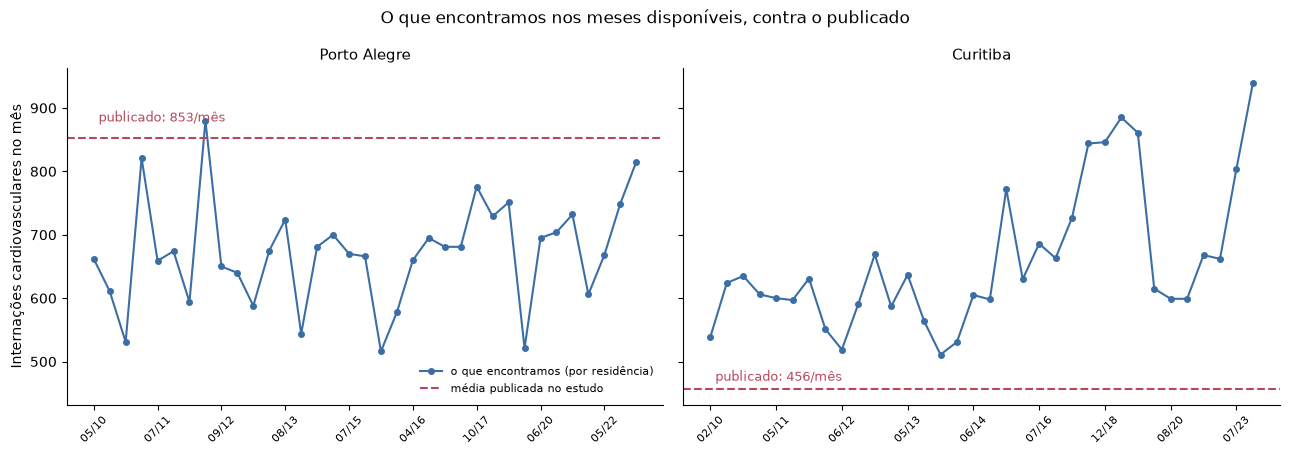

In [7]:
figura, eixos = plt.subplots(1, 2, figsize=(13, 4.6), sharey=True)
for eixo, item in zip(eixos, comparacao):
    serie = item["_serie"].sort_values(["ano", "mes"])
    rotulos = [f"{r.mes:02d}/{str(r.ano)[2:]}" for r in serie.itertuples()]
    eixo.plot(range(len(serie)), serie["residencia"], marker="o",
              color="#3b6ea5", linewidth=1.5, markersize=4,
              label="o que encontramos (por residência)")
    eixo.axhline(item["Publicado"], color="#b5495b",
                 linestyle="--", linewidth=1.5, label="média publicada no estudo")
    eixo.text(0.3, item["Publicado"] * 1.03,
              f"publicado: {item['Publicado']}/mês",
              color="#b5495b", fontsize=9)
    eixo.set_title(item["Cidade"], fontsize=11)
    eixo.set_xticks(range(0, len(serie), max(1, len(serie) // 8)))
    eixo.set_xticklabels(rotulos[::max(1, len(serie) // 8)], rotation=45, fontsize=8)
    eixo.spines[["top", "right"]].set_visible(False)

eixos[0].set_ylabel("Internações cardiovasculares no mês")
eixos[0].legend(frameon=False, fontsize=8, loc="lower right")
plt.suptitle("O que encontramos nos meses disponíveis, contra o publicado",
             fontsize=12)
plt.tight_layout()
plt.show()

## 3. A pergunta central, com a série completa

O estudo conclui que o risco de evento cardiovascular é **maior quando faz mais
frio**. Para testar isso não bastam meses esparsos: é preciso o ano inteiro,
vários anos.

O SIM tem exatamente isso — todos os dias, de 1996 até hoje. A troca é de
desfecho: em vez de **internação**, medimos **óbito** pela mesma lista de
causas. É um desfecho mais grave e mais raro, mas registrado com muito mais
completude — e é o desfecho da literatura internacional que o artigo cita.

In [8]:
from pysus import sim

ANOS = list(range(2015, 2024))
ESTADOS = {
    "RS": "Rio Grande do Sul (temperado)",
    "SC": "Santa Catarina (temperado)",
    "CE": "Ceará (tropical)",
    "AM": "Amazonas (tropical)",
}

def obitos_por_mes(uf, anos):
    "Óbitos cardiovasculares por mês do ano, somando todos os anos."
    caminhos = [c.replace("\\", "/") for c in sim(uf, anos)]
    lista = ", ".join(f"'{c}'" for c in caminhos)
    return con.execute(f"""
        SELECT CAST(substr(DTOBITO, 3, 2) AS INTEGER) AS mes, count(*) AS obitos
        FROM read_parquet([{lista}])
        WHERE substr(CAUSABAS, 1, 1) = 'I'
          AND TRY_CAST(substr(CAUSABAS, 2, 2) AS INTEGER) IN ({lista_codigos})
        GROUP BY 1 ORDER BY 1
    """).df().set_index("mes")["obitos"]

MESES = ["jan", "fev", "mar", "abr", "mai", "jun",
         "jul", "ago", "set", "out", "nov", "dez"]

sazonal = pd.DataFrame({rotulo: obitos_por_mes(uf, ANOS)
                        for uf, rotulo in ESTADOS.items()})
sazonal.index = MESES

print(f"Óbitos cardiovasculares por mês, {ANOS[0]} a {ANOS[-1]}, "
      f"pela definição do estudo\n")
print(f"Total analisado: {mil(sazonal.values.sum())} óbitos")
sazonal

Óbitos cardiovasculares por mês, 2015 a 2023, pela definição do estudo

Total analisado: 250.874 óbitos


,Rio Grande do Sul (temperado),Santa Catarina (temperado),Ceará (tropical),Amazonas (tropical)
jan,9415,4080,4914,1365
fev,8057,3668,4779,1227
mar,9152,4058,5519,1332
abr,9171,4063,5568,1314
mai,10936,4660,5548,1384
jun,11923,4879,5025,1374
jul,12663,5118,5114,1294
ago,11677,4786,4935,1360
set,10197,4454,4748,1197
out,10139,4374,4956,1344


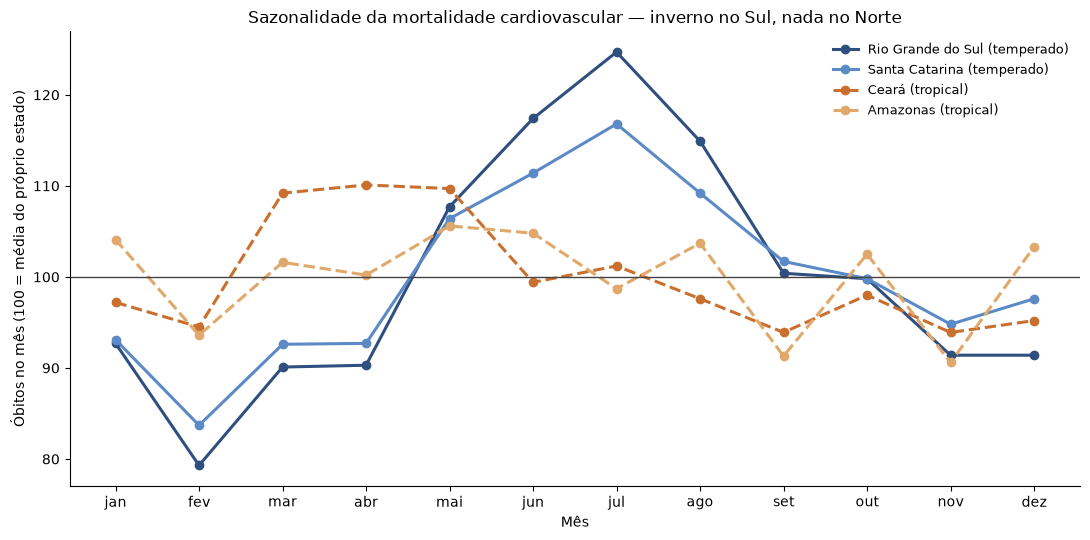

,Rio Grande do Sul (temperado),Santa Catarina (temperado),Ceará (tropical),Amazonas (tropical)
jan,92.7,93.1,97.2,104.1
fev,79.3,83.7,94.5,93.6
mar,90.1,92.6,109.2,101.6
abr,90.3,92.7,110.1,100.2
mai,107.7,106.4,109.7,105.6
jun,117.4,111.4,99.4,104.8
jul,124.7,116.8,101.2,98.7
ago,114.9,109.2,97.6,103.7
set,100.4,101.7,93.9,91.3
out,99.8,99.8,98.0,102.5


In [9]:
# Cada estado na sua própria escala: 100 = a média mensal daquele estado.
# Sem isso, compararíamos tamanho de população, não sazonalidade.
relativo = (sazonal / sazonal.mean() * 100).round(1)

figura, eixo = plt.subplots(figsize=(11, 5.5))
cores = {"Rio Grande do Sul (temperado)": "#2f4f7f",
         "Santa Catarina (temperado)": "#5b8ac6",
         "Ceará (tropical)": "#c9702f",
         "Amazonas (tropical)": "#e0a86a"}

for coluna in relativo.columns:
    estilo = "-" if "temperado" in coluna else "--"
    eixo.plot(MESES, relativo[coluna], marker="o", linewidth=2.2,
              linestyle=estilo, color=cores[coluna], label=coluna)

eixo.axhline(100, color="#444", linewidth=1)
eixo.set_ylabel("Óbitos no mês (100 = média do próprio estado)")
eixo.set_xlabel("Mês")
eixo.set_title("Sazonalidade da mortalidade cardiovascular — inverno no Sul, "
               "nada no Norte", fontsize=12)
eixo.legend(frameon=False, fontsize=9)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

relativo

O gráfico responde à pergunta do estudo com uma clareza que dispensa modelo.

Nos estados **temperados**, julho — o auge do inverno — traz cerca de um quarto
mais óbitos que a média do ano, e fevereiro traz um quinto a menos. Nos estados
**tropicais**, a linha é quase reta: o mês do ano quase não importa.

É o mesmo achado do artigo e da literatura internacional que ele cita: o frio,
e não o calor, é o que pesa sobre o coração.

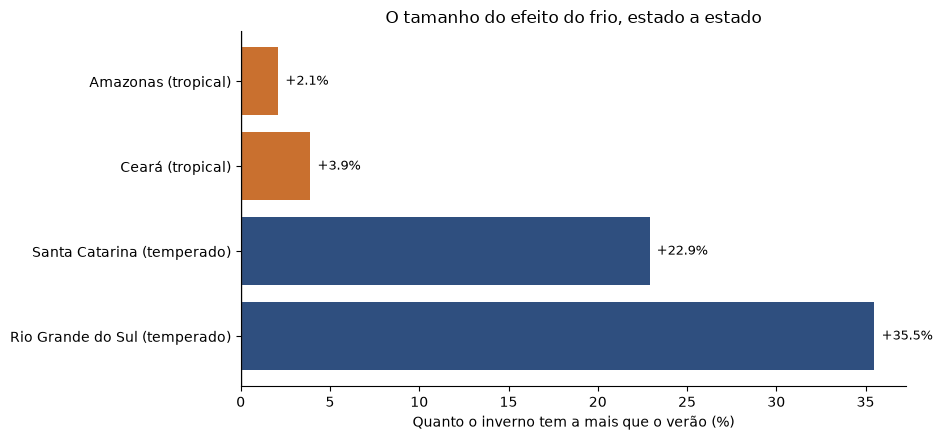

,Óbitos no inverno / no verão,Excesso de inverno (%)
Rio Grande do Sul (temperado),1.355,35.5
Santa Catarina (temperado),1.229,22.9
Ceará (tropical),1.039,3.9
Amazonas (tropical),1.021,2.1


In [10]:
def razao_inverno_verao(coluna):
    inverno = sazonal[coluna].iloc[[5, 6, 7]].sum()      # jun, jul, ago
    verao = sazonal[coluna].iloc[[11, 0, 1]].sum()       # dez, jan, fev
    return inverno / verao

razoes = pd.Series({c: razao_inverno_verao(c) for c in sazonal.columns}).round(3)
excesso = ((razoes - 1) * 100).round(1)

quadro_final = pd.DataFrame({
    "Óbitos no inverno / no verão": razoes,
    "Excesso de inverno (%)": excesso,
}).sort_values("Óbitos no inverno / no verão", ascending=False)

figura, eixo = plt.subplots(figsize=(9.5, 4.5))
cores_barra = ["#2f4f7f" if "temperado" in i else "#c9702f"
               for i in quadro_final.index]
eixo.barh(quadro_final.index, quadro_final["Excesso de inverno (%)"],
          color=cores_barra)
eixo.axvline(0, color="#444", linewidth=1)
for indice, valor in enumerate(quadro_final["Excesso de inverno (%)"]):
    eixo.text(valor + 0.4, indice, f"+{valor:.1f}%", va="center", fontsize=9)
eixo.set_xlabel("Quanto o inverno tem a mais que o verão (%)")
eixo.set_title("O tamanho do efeito do frio, estado a estado", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

quadro_final

Um número para levar: no Rio Grande do Sul morre-se **cerca de um terço mais**
de causa cardiovascular no inverno que no verão. No Amazonas, a diferença é de
2%, ou seja, nenhuma.

Vale registrar uma nuance em relação ao artigo. Ele **não** encontrou diferença
de risco entre as regiões de clima temperado e tropical; nós encontramos uma
diferença enorme na sazonalidade. Não é contradição: são medidas distintas. O
estudo comparou o risco associado a uma dada temperatura — e faz sentido que
15 °C pesem parecido em qualquer lugar. Nós comparamos quanto o calendário
mexe com cada região — e no Norte o calendário simplesmente não traz frio.

## 4. Conferindo com a realidade

In [11]:
rs = "Rio Grande do Sul (temperado)"
am = "Amazonas (tropical)"

print("Verificações de sanidade\n")
print("1. Nossas contagens têm a mesma ordem de grandeza do publicado?")
for linha in quadro.itertuples():
    razao = getattr(linha, "_6")          # Razão (residência)
    print(f"   {linha.Cidade:<14} razão {razao:.2f} "
          f"({'sim' if 0.5 <= razao <= 2.0 else 'ATENÇÃO'})")
print("   (não se espera coincidência exata: veja a discussão da seção 2)")
print(f"2. Pico de óbitos no inverno nos estados temperados?")
print(f"   {rs}: pico em {sazonal[rs].idxmax()} "
      f"({'sim' if sazonal[rs].idxmax() in ('jun', 'jul', 'ago') else 'ATENÇÃO'})")
print(f"3. Sazonalidade maior no Sul que no Norte?")
print(f"   {razoes[rs]:.2f} contra {razoes[am]:.2f} "
      f"({'sim' if razoes[rs] > razoes[am] else 'ATENÇÃO'})")
print(f"4. Volume compatível com o país?")
print(f"   {mil(sazonal.values.sum())} óbitos em 4 estados e {len(ANOS)} anos")
print("   O Brasil registra cerca de 400 mil óbitos cardiovasculares por ano;")
print("   estes quatro estados somam perto de 15% da população.")

Verificações de sanidade

1. Nossas contagens têm a mesma ordem de grandeza do publicado?
   Porto Alegre   razão 0.79 (sim)
   Curitiba       razão 1.45 (sim)
   (não se espera coincidência exata: veja a discussão da seção 2)
2. Pico de óbitos no inverno nos estados temperados?
   Rio Grande do Sul (temperado): pico em jul (sim)
3. Sazonalidade maior no Sul que no Norte?
   1.35 contra 1.02 (sim)
4. Volume compatível com o país?
   250.874 óbitos em 4 estados e 9 anos
   O Brasil registra cerca de 400 mil óbitos cardiovasculares por ano;
   estes quatro estados somam perto de 15% da população.


## 5. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outros estados | edite `ESTADOS` — vale a pena incluir um do Centro-Oeste |
| Outro período | `ANOS = list(range(2010, 2025))` |
| Só infarto | filtre `grupo_cardiovascular(cid) == "Infarto agudo do miocárdio"` |
| Por sexo ou faixa etária | acrescente `SEXO` e `IDADE` à consulta do SIM (veja o notebook de mortalidade prematura) |
| Por município | troque `CAUSABAS`/UF por `CODMUNRES` |
| Internações em vez de óbitos | use a função `cardiovasculares_no_mes`, lembrando das lacunas do SIH |

### Para uma replicação completa faltaria

**Temperatura diária**, das estações do INMET, associadas a cada município.
**A série contínua do SIH**, que exigiria baixar os arquivos do DATASUS por
fora do espelho usado aqui.
**O modelo DLNM**, que descreve o efeito não linear e retardado da
temperatura — o frio de hoje ainda pesa daqui a duas semanas.

### O que este notebook mostra sobre confiar em dados

O achado que se replicou não foi um número — foi **um resultado**. A
sazonalidade cardiovascular apareceu forte no Sul e ausente no Norte, com a
mesma definição de caso do artigo e dados independentes. Conclusões robustas
sobrevivem a mudanças de desfecho e de recorte; foi o que aconteceu aqui.

As **contagens**, essas não se replicaram: nenhuma das duas cidades bateu, e
elas erraram para lados opostos. Testamos a explicação mais provável e ela não
se sustentou.

Vale como aviso de mão dupla. Ao ler um estudo, não presuma que você chegaria
ao mesmo número com a mesma base — a distância entre "os dados são públicos" e
"o resultado é reproduzível" é maior do que parece. E ao publicar o seu, feche
essa distância: diga se contou por residência ou por internação, o que
excluiu, e por quê.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Estudo replicado parcialmente: Dóris B, Savogin Andraus G, Seunarine RS e cols.
Association between climatic variables and cardiovascular hospitalizations in
Brazil: An ecological study. PLOS Glob Public Health 6(7): e0005294 (2026).
Dados: SIH/SUS e SIM/DATASUS, via biblioteca
[PySUS](https://github.com/AlertaDengue/PySUS). Notebook executado de verdade
antes de publicado.*